# Patient-Calibrated 3-Stage Random Forest (v4 - Publication Ready)

**Overview: The Patient-Calibrated Paradigm**

This notebook evaluates a patient-calibrated Random Forest pipeline for classifying 3 sleep stages (Wake, NREM, REM) using exclusively wrist accelerometer data from the PhysioNet *Motion and Heart Rate from a Wrist-Worn Wearable and Labeled Sleep from Polysomnography* dataset (31 subjects).

**Key methodological features:**
- **44 features**: spectral, inter-axis correlations, subject-normalized z-scores, lagged epochs, stillness run length, VM percentile rank, power ratios, multi-scale rolling windows (2m, 5m, 15m, 30m)
- **Pre-sleep data clipping**: drops motion data before first PSG label to reduce memory and compute
- **GroupKFold (5 splits)**: entire subjects held out per fold — no subject leakage across train/test boundary
- **Nested threshold selection**: REM and Wake thresholds are tuned on the *other 4 folds* for each test fold, preventing post-hoc optimization bias
- **Majority-class baseline**: ZeroR comparison to contextualize RF gains
- **Bootstrap 95% CIs** for macro F1 and Cohen's Kappa
- **McNemar's test**: statistical significance of RF vs. baseline
- **Minimum bout enforcement**: optional post-processing removing bouts < 3 min; applied only if it improves OOF F1

**v4 corrections over v3:**
- Nested threshold CV eliminates test-set threshold leakage present in v3
- `roll_mean_std_vm_*` naming corrected (was misleadingly labelled `roll_std_vm_*`)
- Dead `compute_epoch_features` function removed; `safe_corr` moved outside loop
- Statistical reporting: baseline comparison, CIs, McNemar's test added

In [1]:
# Install all required dependencies
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'pandas', 'numpy', 'scikit-learn', 'imbalanced-learn',
    'matplotlib', 'seaborn', 'scipy', 'statsmodels'
], check=True)

CompletedProcess(args=['c:\\Users\\Ben Keizer\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'scikit-learn', 'imbalanced-learn', 'matplotlib', 'seaborn', 'scipy', 'statsmodels'], returncode=0)

## 1. Unzip and Load Data

### Subtask: Raw Data Extraction and Ingestion

This module handles the extraction and ingestion of the raw dataset. We systematically load the high-frequency wrist actigraphy (accelerometer x, y, z) and the corresponding Polysomnography (PSG) labels into isolated Pandas DataFrames. Critically, we intentionally exclude all photoplethysmography (heart rate) data files. This enforces our core research constraint: evaluating the predictive power of computational motion analysis isolated from physiological metrics.

In [2]:
import zipfile
import os
import pandas as pd

# --- 1.A Dataset Extraction ---
zip_path = r'C:\Users\Ben Keizer\Desktop\BME1580 Models\heartratedata.zip'
extract_path = r'C:\Users\Ben Keizer\Desktop\BME1580 Models\heartratedata'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("Extraction skipped: folder already exists.")

base_path = os.path.join(extract_path, 'motion-and-heart-rate-from-a-wrist-worn-wearable-and-labeled-sleep-from-polysomnography-1.0.0')
motion_dir = os.path.join(base_path, 'motion')
labels_dir = os.path.join(base_path, 'labels')

motion_list = []
labels_list = []
subject_ids = []

# --- 1.B Dynamic File Discovery ---
if os.path.exists(motion_dir):
    for filename in os.listdir(motion_dir):
        if filename.endswith('_acceleration.txt'):
            subject_id = filename.split('_')[0]
            subject_ids.append(subject_id)

# Deterministic subject ordering for reproducibility
subject_ids = sorted(subject_ids)

print(f"Discovered {len(subject_ids)} individual subjects.")

# --- 1.C Data Ingestion Loop ---
for subject_id in subject_ids:
    motion_file = os.path.join(motion_dir, f"{subject_id}_acceleration.txt")
    if os.path.exists(motion_file):
        try:
            df_m = pd.read_csv(motion_file, sep=' ', header=None, names=['timestamp', 'x', 'y', 'z'])
            df_m['subject_id'] = subject_id
            motion_list.append(df_m)
        except Exception as e:
            print(f"Error reading motion file for {subject_id}: {e}")

    label_file = os.path.join(labels_dir, f"{subject_id}_labeled_sleep.txt")
    if os.path.exists(label_file):
        try:
            df_l = pd.read_csv(label_file, sep=' ', header=None, names=['timestamp', 'label'])
            df_l['subject_id'] = subject_id
            labels_list.append(df_l)
        except Exception as e:
            print(f"Error reading label file for {subject_id}: {e}")

# --- 1.D DataFrame Concatenation ---
if motion_list:
    motion_df = pd.concat(motion_list, ignore_index=True)
    print("Motion Data successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Motion Data Found.")

if labels_list:
    labels_df = pd.concat(labels_list, ignore_index=True)
    print("PSG Labels successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Labels Data Found.")

# --- 1.E Clip pre-sleep motion data (timestamps before first label) ---
# Motion files start ~6-7 hours before labels; drop those rows to avoid
# wasting compute on data that will be discarded after merge_asof.
motion_df['timestamp']  = motion_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['timestamp']  = labels_df['timestamp'].astype(float)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)
label_start = labels_df.groupby('subject_id')['timestamp'].min().rename('label_start')
motion_df = motion_df.join(label_start, on='subject_id')
motion_df = motion_df[motion_df['timestamp'] >= motion_df['label_start'] - 30].copy()
motion_df.drop(columns='label_start', inplace=True)
print(f"Motion rows after pre-sleep clip: {len(motion_df):,}")

Extraction skipped: folder already exists.
Discovered 31 individual subjects.
Motion Data successfully loaded into memory.
PSG Labels successfully loaded into memory.
Motion rows after pre-sleep clip: 49,200,766


## 2. Data Synchronization and Label Processing

### Subtask: Temporal Alignment and Macro-Class Grouping

High-frequency raw motion data cannot be directly trained against 30-second sleep epoch labels. This section standardizes the dataset by casting timestamps to compatible formats and employing a backward-filling merge_asof function with a 30-second tolerance guard. For this baseline model, we structurally group the clinical N1, N2, and N3 stages into a single "NREM" macro-class to address clinical practicality and mitigate the extreme class imbalances found in higher-resolution staging.

In [3]:
# --- 2.A Sleep Stage Label Mapping ---
label_map = {
    0: 'Wake',
    1: 'NREM',
    2: 'NREM',
    3: 'NREM',
    5: 'REM'
}

labels_df = labels_df[labels_df['label'].isin(label_map.keys())].copy()
labels_df['sleep_stage'] = labels_df['label'].map(label_map)

# --- 2.B Data Type Standardization ---
labels_df['timestamp'] = labels_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)

# --- 2.C Per-Subject Temporal Sorting (Fix: sort by subject first to avoid cross-subject timestamp overlap) ---
motion_df = motion_df.sort_values(by='timestamp').reset_index(drop=True)
labels_df = labels_df.sort_values(by='timestamp').reset_index(drop=True)

# --- 2.D Temporal Synchronization ---
merged_df = pd.merge_asof(motion_df, labels_df, on='timestamp', by='subject_id',
                           direction='backward', tolerance=30)

merged_df = merged_df.dropna(subset=['sleep_stage'])

print("Class Distribution in Synchronized Dataset:")
print(merged_df['sleep_stage'].value_counts())

Class Distribution in Synchronized Dataset:
sleep_stage
NREM    26858242
REM      8104858
Wake     3322442
Name: count, dtype: int64


## 3. Time-Series Feature Engineering (Enhanced v3)

### Subtask: 44-Feature Matrix Including Subject-Normalized and Temporal Context Features

Feature groups (44 total, up from 26):

- **Base motion** (4): mean, std, max, range of vector magnitude
- **Wrist orientation** (2): mean and std tilt angle
- **Inter-axis correlations** (3): xy, xz, yz Pearson r
- **Spectral** (7): entropy, dominant freq, low/high power, ZCR, power ratio, total power
- **Temporal/circadian** (4): time of night, VM delta 1-step, VM delta 2-step, time since last movement
- **Multi-scale rolling windows** (8): mean and std VM at 2m, 5m, 15m, 30m
- **Subject Z-score normalized** (8, NEW): z-normalized motion/spectral features per subject
- **VM percentile rank** (1, NEW): where this epoch falls in the subject's personal motion distribution
- **Lagged epochs** (6, NEW): mean_vm at +/-1, +/-2, +/-3 epochs for temporal context
- **Stillness run length** (1, NEW): consecutive epochs at or below subject's 15th percentile motion

Memory optimization: merged_df (~38M rows) is released after feature extraction.

In [4]:
import numpy as np

# --- 3.A Per-Sample Feature Precomputation ---
merged_df['epoch_start'] = (merged_df['timestamp'] // 30) * 30
merged_df['vm'] = np.sqrt(merged_df['x']**2 + merged_df['y']**2 + merged_df['z']**2)
merged_df['tilt_angle'] = np.arctan2(merged_df['z'],
                          np.sqrt(merged_df['x']**2 + merged_df['y']**2))

# --- 3.B Base Epoch Aggregation ---
epoch_df = merged_df.groupby(['subject_id', 'epoch_start']).agg(
    mean_vm=('vm', 'mean'),
    std_vm=('vm', 'std'),
    max_vm=('vm', 'max'),
    range_vm=('vm', lambda x: x.max() - x.min()),
    mean_tilt=('tilt_angle', 'mean'),
    std_tilt=('tilt_angle', 'std'),
    sleep_stage=('sleep_stage', 'first')
).reset_index()

# --- 3.C Spectral Features + ZCR + Inter-Axis Correlations + Spectral Ratios ---
# safe_corr defined once outside the loop to avoid repeated function object creation.
def safe_corr(a, b):
    if len(a) < 2: return 0.0
    sa, sb = a.std(), b.std()
    if sa == 0 or sb == 0: return 0.0
    return float(np.corrcoef(a, b)[0, 1])

print("Computing spectral + inter-axis + ratio features per epoch...")
records = []
for (sid, es), group in merged_df.groupby(['subject_id', 'epoch_start']):
    vm = group['vm'].values
    x_vals, y_vals, z_vals = group['x'].values, group['y'].values, group['z'].values
    n = len(vm)
    row = {'subject_id': sid, 'epoch_start': es}
    if n >= 8:
        fs = n / 30.0
        fft_vals = np.abs(np.fft.rfft(vm))
        freqs = np.fft.rfftfreq(n, d=1.0 / fs)
        fft_norm = fft_vals / (fft_vals.sum() + 1e-10)
        row['spectral_entropy'] = float(-np.sum(fft_norm * np.log(fft_norm + 1e-10)))
        row['dominant_freq'] = float(freqs[np.argmax(fft_vals[1:]) + 1]) if len(fft_vals) > 1 else 0.0
        row['power_low']  = float(fft_vals[(freqs >= 0.3) & (freqs < 1.0)].sum())
        row['power_high'] = float(fft_vals[(freqs >= 1.0) & (freqs < 3.0)].sum())
        row['power_ratio'] = row['power_high'] / (row['power_low'] + 1e-10)
        row['total_power'] = row['power_low'] + row['power_high']
        vm_c = vm - vm.mean()
        row['zcr'] = float(np.sum(np.diff(np.sign(vm_c)) != 0) / n)
    else:
        row.update({'spectral_entropy': 0.0, 'dominant_freq': 0.0,
                    'power_low': 0.0, 'power_high': 0.0, 'zcr': 0.0,
                    'power_ratio': 0.0, 'total_power': 0.0})
    row['xy_corr'] = safe_corr(x_vals, y_vals)
    row['xz_corr'] = safe_corr(x_vals, z_vals)
    row['yz_corr'] = safe_corr(y_vals, z_vals)
    records.append(row)
extra_df = pd.DataFrame(records)
epoch_df = epoch_df.merge(extra_df, on=['subject_id', 'epoch_start'], how='left')
print(f"Extra features computed. Epoch count: {len(epoch_df):,}")

# --- 3.D Multi-Scale Rolling Windows (2m, 5m, 15m, 30m) ---
# roll_mean_std_vm_* = rolling mean of per-epoch std_vm (smoothed volatility proxy).
epoch_df = epoch_df.sort_values(by=['subject_id', 'epoch_start'])
for window, label in [(4, '2m'), (10, '5m'), (30, '15m'), (60, '30m')]:
    epoch_df[f'roll_mean_vm_{label}'] = epoch_df.groupby('subject_id')['mean_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )
    epoch_df[f'roll_mean_std_vm_{label}'] = epoch_df.groupby('subject_id')['std_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )

# --- 3.E Circadian and Temporal Delta Features ---
epoch_df['time_of_night_hours'] = (
    epoch_df.groupby('subject_id')['epoch_start']
    .transform(lambda x: (x - x.min()) / 3600.0)
)
epoch_df['vm_delta']   = epoch_df.groupby('subject_id')['mean_vm'].diff().fillna(0)
epoch_df['vm_delta_2'] = epoch_df.groupby('subject_id')['mean_vm'].diff(2).fillna(0)

# --- 3.F Dynamic Rest-Activity Thresholding ---
baseline = epoch_df.groupby('subject_id')['mean_vm'].transform(lambda x: x.quantile(0.05))
epoch_df['is_movement'] = epoch_df['mean_vm'] > (baseline + 0.05)
epoch_df['last_movement_time'] = (
    epoch_df['epoch_start'].where(epoch_df['is_movement'])
    .groupby(epoch_df['subject_id']).ffill()
)
epoch_df['time_since_last_movement'] = (
    epoch_df['epoch_start'] - epoch_df['last_movement_time'].fillna(epoch_df['epoch_start'])
)
epoch_df.drop(columns=['is_movement', 'last_movement_time'], inplace=True)

# --- 3.G Fill NaN values ---
epoch_df.columns = epoch_df.columns.astype(str)
epoch_df['std_vm'] = epoch_df['std_vm'].fillna(0)
epoch_df['time_since_last_movement'] = epoch_df['time_since_last_movement'].ffill().fillna(0)
for col in [c for c in epoch_df.columns if c.startswith('roll_')]:
    epoch_df[col] = epoch_df[col].fillna(0)
for col in ['xy_corr', 'xz_corr', 'yz_corr',
            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
            'mean_tilt', 'std_tilt', 'power_ratio', 'total_power']:
    if col in epoch_df.columns:
        epoch_df[col] = epoch_df[col].fillna(0)

# --- 3.H Subject-Normalized Z-Score Features ---
print("Computing subject-normalized z-score features...")
motion_features_to_norm = ['mean_vm', 'std_vm', 'max_vm', 'range_vm',
                            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high']
for feat in motion_features_to_norm:
    if feat in epoch_df.columns:
        epoch_df[f'{feat}_znorm'] = epoch_df.groupby('subject_id')[feat].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )

# --- 3.I VM Percentile Rank Within Subject ---
epoch_df['vm_percentile_rank'] = epoch_df.groupby('subject_id')['mean_vm'].rank(pct=True)

# --- 3.J Lagged Epoch Features +/-1, +/-2, +/-3 ---
print("Computing lagged epoch features...")
for lag in [-3, -2, -1, 1, 2, 3]:
    col_name = f'mean_vm_lag_{lag}'
    epoch_df[col_name] = epoch_df.groupby('subject_id')['mean_vm'].shift(-lag)
    epoch_df[col_name] = epoch_df.groupby('subject_id')[col_name].transform(
        lambda x: x.ffill().bfill()
    )

# --- 3.K Stillness Run Length ---
print("Computing stillness run length...")
def compute_stillness_run(group):
    thresh = group['mean_vm'].quantile(0.15)
    still = group['mean_vm'] <= thresh
    run_len = []
    count = 0
    for val in still:
        count = count + 1 if val else 0
        run_len.append(count)
    return pd.Series(run_len, index=group.index)

epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(
    compute_stillness_run
)

# Memory cleanup
del merged_df
import gc; gc.collect()
print("\nMemory cleanup: merged_df released.")

print(f"\nFinal epoch_df shape: {epoch_df.shape}")
all_features = [c for c in epoch_df.columns if c not in ['subject_id', 'epoch_start', 'sleep_stage']]
print(f"Total features available: {len(all_features)}")
print(all_features)

Computing spectral + inter-axis + ratio features per epoch...
Extra features computed. Epoch count: 25,199
Computing subject-normalized z-score features...
Computing lagged epoch features...
Computing stillness run length...


C:\Users\Ben Keizer\AppData\Local\Temp\ipykernel_9716\3447331968.py:137: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(



Memory cleanup: merged_df released.

Final epoch_df shape: (25199, 47)
Total features available: 44
['mean_vm', 'std_vm', 'max_vm', 'range_vm', 'mean_tilt', 'std_tilt', 'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'power_ratio', 'total_power', 'zcr', 'xy_corr', 'xz_corr', 'yz_corr', 'roll_mean_vm_2m', 'roll_mean_std_vm_2m', 'roll_mean_vm_5m', 'roll_mean_std_vm_5m', 'roll_mean_vm_15m', 'roll_mean_std_vm_15m', 'roll_mean_vm_30m', 'roll_mean_std_vm_30m', 'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement', 'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm', 'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm', 'vm_percentile_rank', 'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1', 'mean_vm_lag_1', 'mean_vm_lag_2', 'mean_vm_lag_3', 'stillness_run_len']


## 4. Random Forest Pipeline and Cross-Validation

### Subtask: Patient-Isolated Evaluation with Majority-Class Baseline

A Random Forest classifier is evaluated using `GroupKFold` (5 splits, grouped by `subject_id`) to ensure no subject appears in both train and test folds. The cross-validation loop is run manually (rather than via `cross_val_predict`) to expose fold assignments, which are required for the nested threshold selection in Section 5.

A majority-class (ZeroR) baseline is computed to provide a lower-bound reference against which all RF gains are measured. The final full-data RF fit is used solely for feature importance extraction.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, cohen_kappa_score
from collections import Counter
import numpy as np
import pandas as pd

# --- 4.A Feature List (44 features) ---
features = [
    # Base motion
    'mean_vm', 'std_vm', 'max_vm', 'range_vm',
    # Wrist orientation
    'mean_tilt', 'std_tilt',
    # Inter-axis correlations
    'xy_corr', 'xz_corr', 'yz_corr',
    # Spectral / frequency-domain
    'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
    'power_ratio', 'total_power',
    # Temporal / circadian
    'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement',
    # Rolling windows – mean of VM and rolling mean of epoch std (smoothed volatility)
    'roll_mean_vm_2m', 'roll_mean_std_vm_2m', 'roll_mean_vm_5m', 'roll_mean_std_vm_5m',
    'roll_mean_vm_15m', 'roll_mean_std_vm_15m', 'roll_mean_vm_30m', 'roll_mean_std_vm_30m',
    # Subject-normalized z-score features
    'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm',
    'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm',
    # Scale-invariant rank
    'vm_percentile_rank',
    # Lagged features
    'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1',
    'mean_vm_lag_1',  'mean_vm_lag_2',  'mean_vm_lag_3',
    # Stillness run length
    'stillness_run_len',
]
target = 'sleep_stage'

missing = [f for f in features if f not in epoch_df.columns]
if missing:
    print(f"Warning: {len(missing)} features not found (dropped): {missing}")
features = [f for f in features if f in epoch_df.columns]

X      = epoch_df[features].values
y      = epoch_df[target]
y_arr  = y.values
groups = epoch_df['subject_id'].values

print(f"Feature matrix: {len(X):,} epochs x {len(features)} features")

# --- 4.B Majority-Class (ZeroR) Baseline ---
# Provides a lower-bound reference: a model that always predicts the dominant class.
majority_class = Counter(y_arr).most_common(1)[0][0]
y_baseline     = np.full(len(y_arr), majority_class)
baseline_f1    = f1_score(y_arr, y_baseline, average='macro', zero_division=0)
baseline_kappa = cohen_kappa_score(y_arr, y_baseline)
print(f"\nMajority-class baseline (always predicts '{majority_class}'):")
print(f"  Macro F1 : {baseline_f1:.4f}")
print(f"  Kappa    : {baseline_kappa:.4f}")

# --- 4.C LOSO Cross-Validation ---
# Leave-One-Subject-Out (LOSO): each of the 31 subjects is held out in turn.
# Preferred over k-fold for small cohorts (N=31) — gives a more reliable
# generalization estimate than 5-fold. Running folds manually exposes fold
# assignments for nested threshold selection in Section 5.
n_subjects   = len(epoch_df['subject_id'].unique())
n_folds      = n_subjects  # one fold per subject
cv           = GroupKFold(n_splits=n_folds)
n_classes    = len(np.unique(y_arr))
oof_probs    = np.zeros((len(X), n_classes))
fold_indices = np.zeros(len(X), dtype=int)

print(f"\nRunning LOSO cross-validation ({n_folds} folds, RF)...")
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y_arr, groups=groups)):
    rf = RandomForestClassifier(
        n_estimators=300, random_state=42, max_depth=15,
        min_samples_leaf=5, class_weight='balanced', n_jobs=-1
    )
    rf.fit(X[train_idx], y_arr[train_idx])
    oof_probs[test_idx]    = rf.predict_proba(X[test_idx])
    fold_indices[test_idx] = fold_idx
    print(f"  Fold {fold_idx + 1}/{n_folds} complete")

# --- 4.D Final Full-Data Fit (feature importances ONLY – never used for evaluation) ---
rf_for_importance = RandomForestClassifier(
    n_estimators=300, random_state=42, max_depth=15,
    min_samples_leaf=5, class_weight='balanced', n_jobs=-1
)
rf_for_importance.fit(epoch_df[features], y)
classes = list(rf_for_importance.classes_)
print(f"\nClasses: {classes}")
print("All evaluation metrics use out-of-fold predictions only.")

# --- 4.E OOF Probability Quantiles (diagnostic) ---
# If p99 < 0.50, the model never confidently predicts that class.
print("\nOOF Probability Quantiles by Class:")
for cls_name in classes:
    idx = classes.index(cls_name)
    q = pd.Series(oof_probs[:, idx]).quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    print(f"  {cls_name:>4}: p50={q.iloc[0]:.3f} p75={q.iloc[1]:.3f} "
          f"p90={q.iloc[2]:.3f} p95={q.iloc[3]:.3f} p99={q.iloc[4]:.3f}")

Feature matrix: 25,199 epochs x 44 features

Majority-class baseline (always predicts 'NREM'):
  Macro F1 : 0.2729
  Kappa    : 0.0000

Running LOSO cross-validation (31 folds, RF)...
  Fold 1/31 complete
  Fold 2/31 complete
  Fold 3/31 complete
  Fold 4/31 complete
  Fold 5/31 complete
  Fold 6/31 complete
  Fold 7/31 complete
  Fold 8/31 complete
  Fold 9/31 complete
  Fold 10/31 complete
  Fold 11/31 complete
  Fold 12/31 complete
  Fold 13/31 complete
  Fold 14/31 complete
  Fold 15/31 complete
  Fold 16/31 complete
  Fold 17/31 complete
  Fold 18/31 complete
  Fold 19/31 complete
  Fold 20/31 complete
  Fold 21/31 complete
  Fold 22/31 complete
  Fold 23/31 complete
  Fold 24/31 complete
  Fold 25/31 complete
  Fold 26/31 complete
  Fold 27/31 complete
  Fold 28/31 complete
  Fold 29/31 complete
  Fold 30/31 complete
  Fold 31/31 complete

Classes: ['NREM', 'REM', 'Wake']
All evaluation metrics use out-of-fold predictions only.

OOF Probability Quantiles by Class:
  NREM: p50=0.5

## 5. Helper Functions, Nested Threshold Selection, and Bout Enforcement

### Subtask: Bias-Free Post-Processing Pipeline

**The leakage problem with standard threshold tuning:** Optimizing thresholds on all OOF predictions at once and then reporting metrics on those same predictions inflates results because the thresholds were chosen to maximize exactly that metric on exactly that data.

**The fix — nested fold-aware threshold selection:** For each fold *k*, thresholds are tuned on the OOF predictions from the *other 4 folds* (the calibration set), then applied to fold *k*'s predictions. Each test fold's threshold is therefore chosen without access to any of its predictions, eliminating post-hoc optimization bias.

**Post-processing pipeline (per subject):**
1. `apply_thresholds()` — argmax base prediction with REM/Wake probability overrides
2. `smooth_predictions()` — rolling mode (window=5 epochs = 2.5 min, centered) to remove implausible rapid transitions
3. `enforce_min_bout()` — removes bouts < 3 min (6 epochs); accepted only if it improves OOF macro F1

In [6]:
from sklearn.metrics import f1_score
from scipy.stats import mode
import numpy as np
import pandas as pd

# ========== HELPER FUNCTIONS ==========

def apply_thresholds(probs, classes, thresh_rem, thresh_wake):
    """
    3-stage threshold classification.
    Base prediction = argmax. Overrides applied in order:
      1. Wake if P(Wake) >= thresh_wake
      2. REM  if P(REM)  >= thresh_rem   (REM takes priority over Wake)
    """
    rem_idx  = classes.index('REM')
    wake_idx = classes.index('Wake')
    base_preds = np.array(classes)[np.argmax(probs, axis=1)]
    y_pred = base_preds.copy()
    y_pred[probs[:, wake_idx] >= thresh_wake] = 'Wake'
    y_pred[probs[:, rem_idx]  >= thresh_rem]  = 'REM'
    return y_pred

def smooth_predictions(y_pred_strings, subject_ids_array, stage_to_int, int_to_stage, window=5):
    """Per-subject rolling mode smoothing (window=5 epochs = 2.5 min, centered)."""
    def rolling_mode(series, w=window):
        return series.rolling(window=w, center=True, min_periods=1).apply(
            lambda x: mode(x, keepdims=False).mode
        )
    y_pred_ints = pd.Series(y_pred_strings).map(stage_to_int).values
    temp_df = pd.DataFrame({'subject_id': subject_ids_array, 'pred': y_pred_ints})
    temp_df['smoothed'] = temp_df.groupby('subject_id')['pred'].transform(
        lambda x: rolling_mode(x)
    ).astype(int)
    return temp_df['smoothed'].map(int_to_stage).values

def enforce_min_bout(y_pred_arr, min_epochs=6):
    """
    Remove bouts shorter than min_epochs (default 6 = 3 min) by replacing
    them with the preceding stage label. Applied per-subject.
    """
    result = y_pred_arr.copy()
    if len(result) == 0:
        return result
    unique_vals = list(dict.fromkeys(result))
    val_to_int  = {v: i for i, v in enumerate(unique_vals)}
    int_arr     = np.array([val_to_int[v] for v in result])
    changes     = np.where(np.diff(int_arr, prepend=int_arr[0] - 1) != 0)[0]
    for i, start in enumerate(changes):
        end = changes[i + 1] if i + 1 < len(changes) else len(result)
        if (end - start) < min_epochs and start > 0:
            result[start:end] = result[start - 1]
    return result

# ========== STAGE MAPPINGS ==========
stage_to_int     = {'NREM': 0, 'REM': 1, 'Wake': 2}
int_to_stage     = {0: 'NREM', 1: 'REM', 2: 'Wake'}
subject_ids_array = epoch_df['subject_id'].values

# ========== NESTED FOLD-AWARE THRESHOLD SELECTION ==========
# For each fold k, thresholds are tuned on the *other 4 folds'* OOF predictions,
# then applied only to fold k. This prevents any test-set information from
# influencing the threshold choice evaluated on that fold.
rem_thresholds  = np.arange(0.30, 0.71, 0.05)
wake_thresholds = np.arange(0.20, 0.61, 0.05)
n_folds         = int(fold_indices.max()) + 1

y_pred_nested   = np.empty(len(y_arr), dtype=object)
nested_thresholds = []

print(f"Nested threshold selection ({n_folds}-fold):")
print(f"  Grid: {len(rem_thresholds)} REM x {len(wake_thresholds)} Wake = "
      f"{len(rem_thresholds) * len(wake_thresholds)} combinations per fold\n")

for fold_k in range(n_folds):
    # Calibration set = all folds except fold_k
    cal_mask  = fold_indices != fold_k
    test_mask = fold_indices == fold_k

    cal_probs    = oof_probs[cal_mask]
    cal_y        = y_arr[cal_mask]
    cal_subjects = subject_ids_array[cal_mask]

    # Tune thresholds on calibration folds
    best_f1, best_tr, best_tw = 0.0, 0.50, 0.50
    for tr in rem_thresholds:
        for tw in wake_thresholds:
            preds        = apply_thresholds(cal_probs, classes, tr, tw)
            preds_smooth = smooth_predictions(preds, cal_subjects, stage_to_int, int_to_stage)
            f1_val       = f1_score(cal_y, preds_smooth, average='macro')
            if f1_val > best_f1:
                best_f1, best_tr, best_tw = f1_val, tr, tw

    nested_thresholds.append((best_tr, best_tw))

    # Apply fold-specific thresholds to this test fold only
    test_preds = apply_thresholds(oof_probs[test_mask], classes, best_tr, best_tw)
    test_sids  = subject_ids_array[test_mask]
    test_preds = smooth_predictions(test_preds, test_sids, stage_to_int, int_to_stage)
    y_pred_nested[test_mask] = test_preds

    print(f"  Fold {fold_k + 1}: REM={best_tr:.2f}, Wake={best_tw:.2f}  "
          f"(cal-set macro F1={best_f1:.4f})")

# ========== MINIMUM BOUT ENFORCEMENT (optional) ==========
# Applied per-subject. Accepted only if it improves OOF macro F1.
y_pred_bout = y_pred_nested.copy()
for sid in np.unique(subject_ids_array):
    smask = subject_ids_array == sid
    y_pred_bout[smask] = enforce_min_bout(y_pred_nested[smask])

f1_no_bout = f1_score(y_arr, y_pred_nested, average='macro')
f1_bout    = f1_score(y_arr, y_pred_bout,   average='macro')
print(f"\nPost-processing comparison:")
print(f"  Without bout enforcement : {f1_no_bout:.4f}")
print(f"  With    bout enforcement : {f1_bout:.4f}")

if f1_no_bout >= f1_bout:
    y_pred_final = y_pred_nested
    print("  → Using WITHOUT bout enforcement (equal or higher F1)")
else:
    y_pred_final = y_pred_bout
    print("  → Using WITH bout enforcement (higher F1)")

Nested threshold selection (31-fold):
  Grid: 9 REM x 9 Wake = 81 combinations per fold

  Fold 1: REM=0.50, Wake=0.40  (cal-set macro F1=0.5591)
  Fold 2: REM=0.40, Wake=0.40  (cal-set macro F1=0.5618)
  Fold 3: REM=0.50, Wake=0.40  (cal-set macro F1=0.5671)
  Fold 4: REM=0.50, Wake=0.40  (cal-set macro F1=0.5624)
  Fold 5: REM=0.50, Wake=0.40  (cal-set macro F1=0.5610)
  Fold 6: REM=0.50, Wake=0.40  (cal-set macro F1=0.5640)
  Fold 7: REM=0.50, Wake=0.40  (cal-set macro F1=0.5617)
  Fold 8: REM=0.50, Wake=0.40  (cal-set macro F1=0.5636)
  Fold 9: REM=0.50, Wake=0.40  (cal-set macro F1=0.5651)
  Fold 10: REM=0.50, Wake=0.40  (cal-set macro F1=0.5630)
  Fold 11: REM=0.50, Wake=0.40  (cal-set macro F1=0.5620)
  Fold 12: REM=0.50, Wake=0.40  (cal-set macro F1=0.5552)
  Fold 13: REM=0.50, Wake=0.40  (cal-set macro F1=0.5624)
  Fold 14: REM=0.50, Wake=0.40  (cal-set macro F1=0.5580)
  Fold 15: REM=0.50, Wake=0.40  (cal-set macro F1=0.5632)
  Fold 16: REM=0.50, Wake=0.40  (cal-set macro F1=

## 6. Final Evaluation Metrics and Statistical Validation

### Subtask: Out-of-Fold Diagnostic Performance with Publication-Grade Statistics

All metrics use `y_pred_final` — OOF predictions with nested-threshold selection and optimal post-processing. Statistical reporting includes:

- **Classification report**: per-class precision, recall, F1; macro and weighted averages
- **Majority-class baseline comparison**: contextualizes absolute performance
- **Bootstrap 95% CIs** (n=1000): uncertainty bounds on macro F1 and Cohen's Kappa
- **McNemar's test**: tests whether the RF's error pattern is statistically significantly different from the baseline
- **Per-class AUC-ROC**: discrimination ability independent of thresholds
- **Calibration curves**: assesses whether predicted probabilities reflect true frequencies
- **OOF probability distributions**: visualizes class separability in probability space

3-Stage RF — Out-of-Fold Results (Nested Threshold Selection)
              precision    recall  f1-score   support

        NREM       0.75      0.73      0.74     17461
         REM       0.35      0.39      0.37      5558
        Wake       0.60      0.53      0.56      2180

    accuracy                           0.64     25199
   macro avg       0.57      0.55      0.56     25199
weighted avg       0.65      0.64      0.65     25199

Cohen's Kappa : 0.2390

─────────────────────────────────────────────
Metric                         RF   Baseline        Δ
─────────────────────────────────────────────
Macro F1                   0.5598     0.2729  +0.2869
Cohen Kappa                0.2390     0.0000  +0.2390
─────────────────────────────────────────────

Bootstrap 95% Confidence Intervals (n=1000 resamples):
  Macro F1 : 0.5598  95% CI [0.5522, 0.5675]
  Kappa    : 0.2390  95% CI [0.2272, 0.2506]

McNemar's Test (RF vs majority-class baseline):
  RF correct, baseline wrong : 3357
  

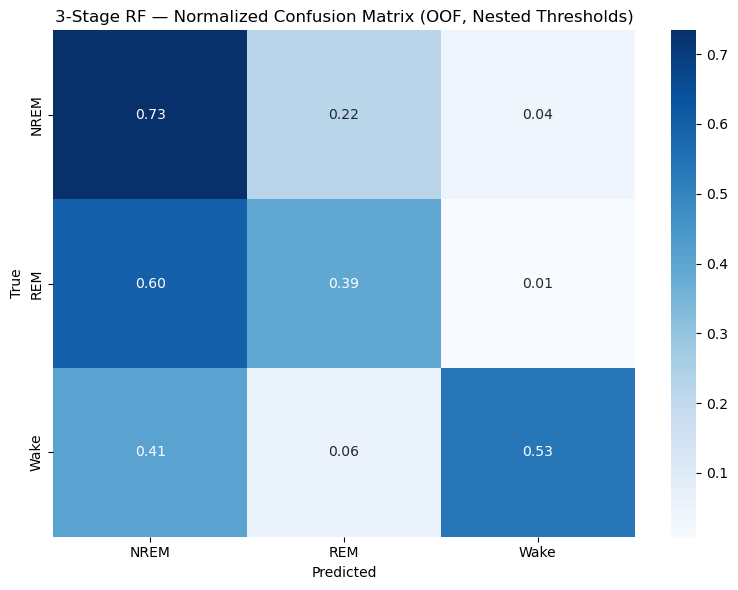

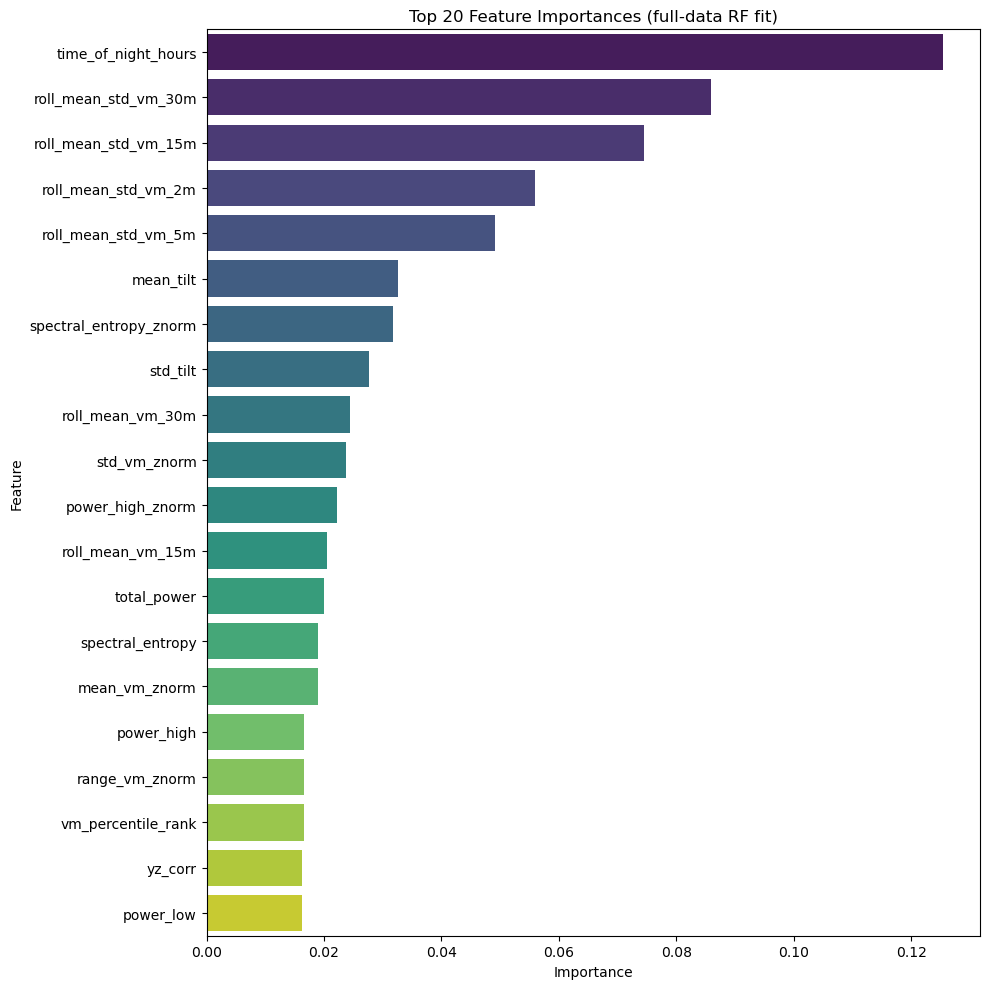


Top 10 features by importance:
               Feature  Importance
   time_of_night_hours    0.125456
  roll_mean_std_vm_30m    0.085941
  roll_mean_std_vm_15m    0.074549
   roll_mean_std_vm_2m    0.055973
   roll_mean_std_vm_5m    0.049150
             mean_tilt    0.032585
spectral_entropy_znorm    0.031692
              std_tilt    0.027579
      roll_mean_vm_30m    0.024401
          std_vm_znorm    0.023701


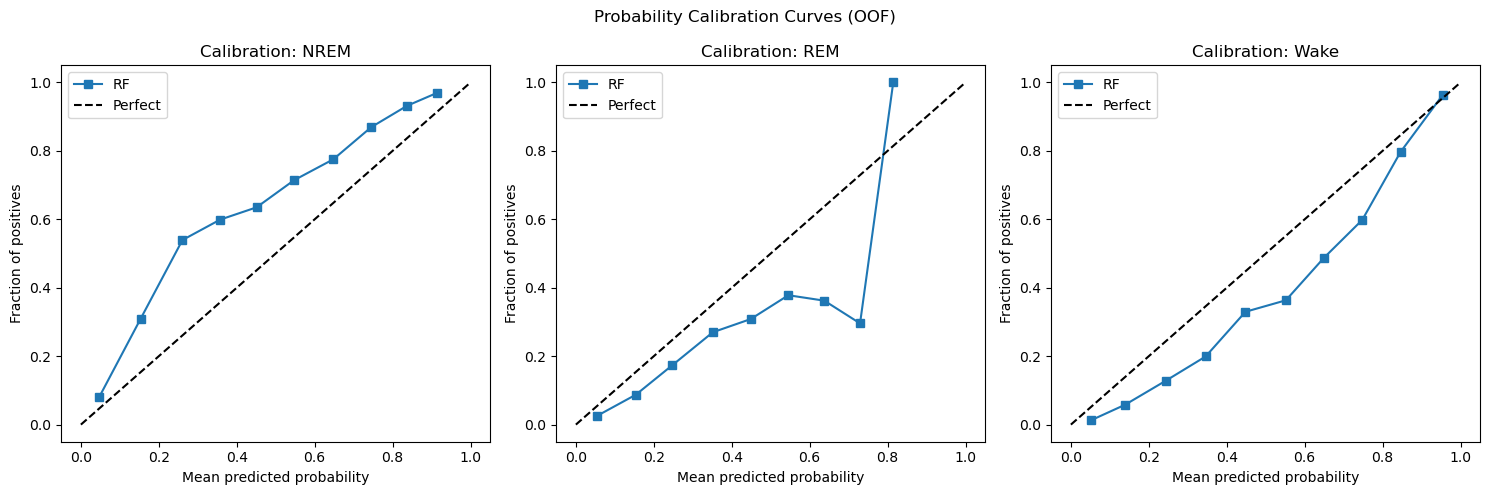

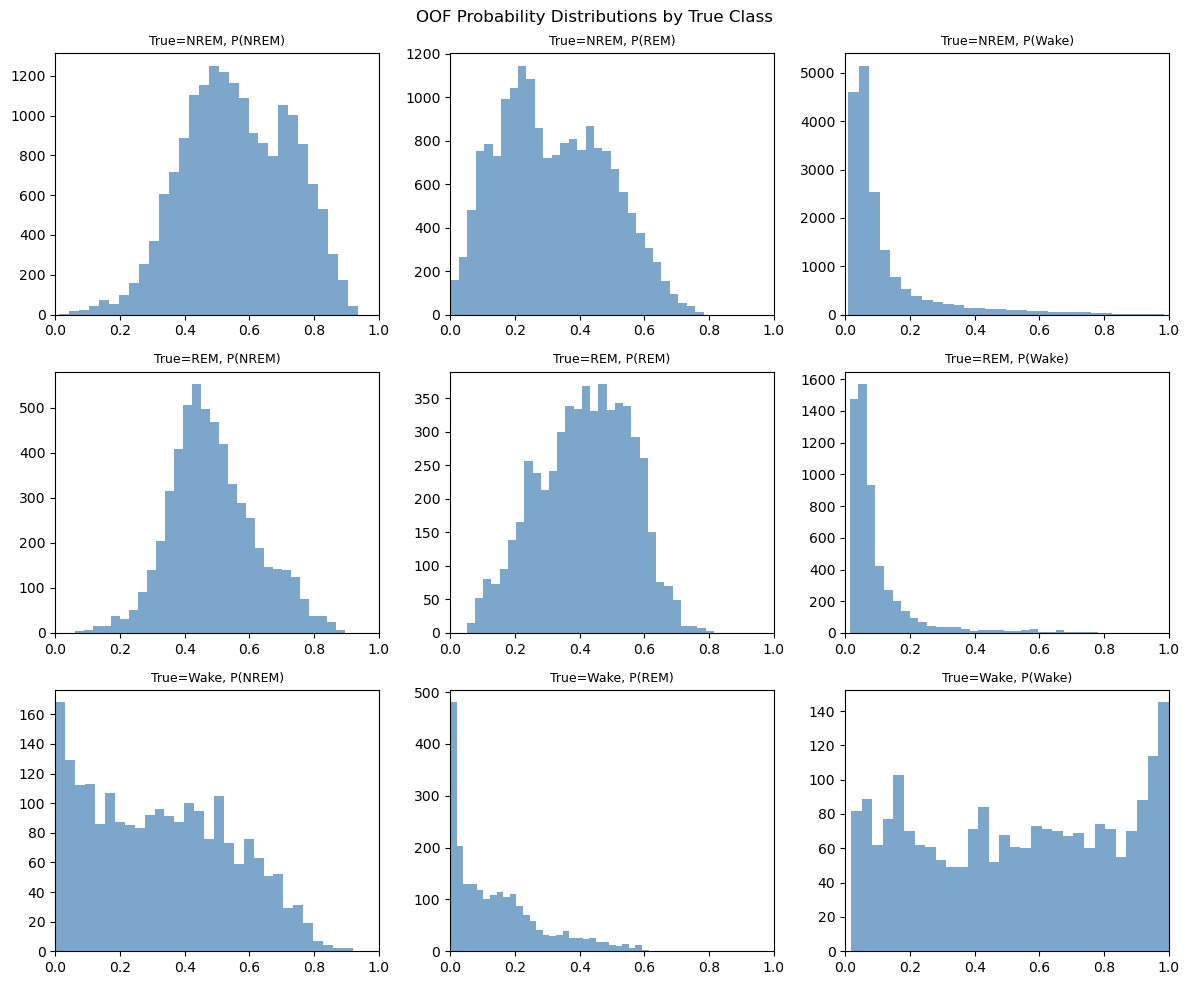


Out-of-Fold Performance Summary (Nested Threshold Selection)
  Accuracy  : 64.19%
  Macro F1  : 0.5598  95% CI [0.5522, 0.5675]
  Kappa     : 0.2390  95% CI [0.2272, 0.2506]
  Baseline Macro F1 : 0.2729
  McNemar p-value   : 8.3682e-47

PER-SUBJECT PERFORMANCE (mean ± SD across subjects)
  Macro F1 : 0.533 ± 0.099  (range 0.328–0.795)
  Cohen's κ: 0.249 ± 0.143  (range -0.054–0.602)
  Accuracy : 0.652 ± 0.106  (range 0.342–0.849)


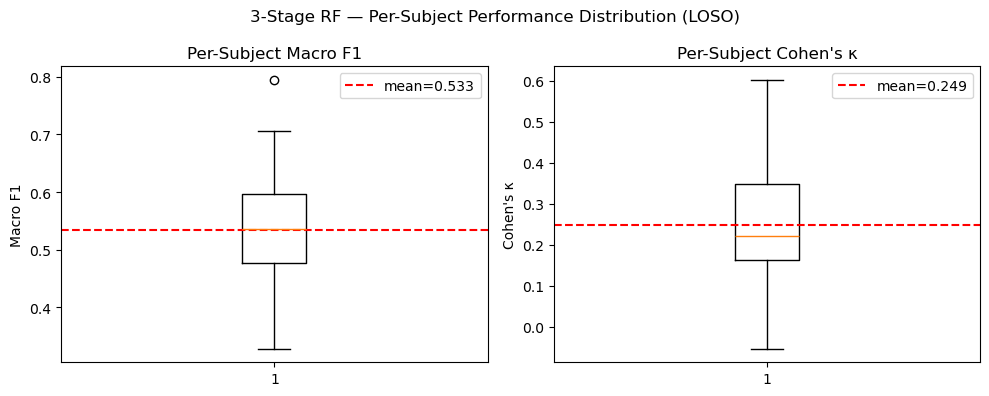

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, roc_auc_score, f1_score)
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

# ========== 6.A CLASSIFICATION REPORT ==========
print("=" * 65)
print("3-Stage RF — Out-of-Fold Results (Nested Threshold Selection)")
print("=" * 65)
print(classification_report(y_arr, y_pred_final, target_names=classes))

kappa      = cohen_kappa_score(y_arr, y_pred_final)
rf_macro_f1 = f1_score(y_arr, y_pred_final, average='macro')
print(f"Cohen's Kappa : {kappa:.4f}")

# ========== 6.B MAJORITY-CLASS BASELINE COMPARISON ==========
print(f"\n{'─'*45}")
print(f"{'Metric':<22} {'RF':>10} {'Baseline':>10} {'Δ':>8}")
print(f"{'─'*45}")
print(f"{'Macro F1':<22} {rf_macro_f1:>10.4f} {baseline_f1:>10.4f} {rf_macro_f1 - baseline_f1:>+8.4f}")
print(f"{'Cohen Kappa':<22} {kappa:>10.4f} {baseline_kappa:>10.4f} {kappa - baseline_kappa:>+8.4f}")
print(f"{'─'*45}")

# ========== 6.C BOOTSTRAP 95% CONFIDENCE INTERVALS ==========
print("\nBootstrap 95% Confidence Intervals (n=1000 resamples):")
np.random.seed(42)
n_boot = 1000
n      = len(y_arr)
boot_f1s, boot_kappas = [], []
for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    boot_f1s.append(f1_score(y_arr[idx], y_pred_final[idx], average='macro', zero_division=0))
    boot_kappas.append(cohen_kappa_score(y_arr[idx], y_pred_final[idx]))

ci_f1    = (np.percentile(boot_f1s, 2.5),    np.percentile(boot_f1s, 97.5))
ci_kappa = (np.percentile(boot_kappas, 2.5), np.percentile(boot_kappas, 97.5))
print(f"  Macro F1 : {rf_macro_f1:.4f}  95% CI [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"  Kappa    : {kappa:.4f}  95% CI [{ci_kappa[0]:.4f}, {ci_kappa[1]:.4f}]")

# ========== 6.D McNEMAR'S TEST vs MAJORITY-CLASS BASELINE ==========
# Tests whether the RF makes significantly different errors than the baseline.
# Off-diagonal counts: b = RF correct & baseline wrong; c = RF wrong & baseline correct.
rf_correct   = (y_pred_final == y_arr)
base_correct = (y_baseline  == y_arr)
b = int(np.sum( rf_correct & ~base_correct))
c = int(np.sum(~rf_correct &  base_correct))
contingency  = [[int(np.sum( rf_correct &  base_correct)), b],
                [c,                                        int(np.sum(~rf_correct & ~base_correct))]]
mc_result    = mcnemar(contingency, exact=False)

print(f"\nMcNemar's Test (RF vs majority-class baseline):")
print(f"  RF correct, baseline wrong : {b}")
print(f"  RF wrong,   baseline correct: {c}")
print(f"  χ² = {mc_result.statistic:.4f},  p = {mc_result.pvalue:.4e}")
if mc_result.pvalue < 0.05:
    print("  → RF is statistically significantly better than majority-class baseline (p < 0.05)")
else:
    print("  → No significant difference from baseline (p ≥ 0.05)")

# ========== 6.E PER-CLASS AUC-ROC ==========
print("\nPer-Class AUC-ROC (One-vs-Rest, OOF probabilities):")
for i, cls in enumerate(classes):
    y_bin = (y_arr == cls).astype(int)
    auc   = roc_auc_score(y_bin, oof_probs[:, i])
    print(f"  AUC ({cls:>4}): {auc:.4f}")

# ========== 6.F CONFUSION MATRIX ==========
cm      = confusion_matrix(y_arr, y_pred_final, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('3-Stage RF — Normalized Confusion Matrix (OOF, Nested Thresholds)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ========== 6.G FEATURE IMPORTANCE ==========
import pandas as pd
importances = rf_for_importance.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(
    'Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=fi_df.head(20),
            palette='viridis', legend=False)
plt.title('Top 20 Feature Importances (full-data RF fit)')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(fi_df.head(10).to_string(index=False))

# ========== 6.H CALIBRATION CURVES ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, cls in enumerate(classes):
    y_bin = (y_arr == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(y_bin, oof_probs[:, i], n_bins=10)
    axes[i].plot(mean_pred, frac_pos, 's-', label='RF')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[i].set_title(f'Calibration: {cls}')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend()
plt.suptitle('Probability Calibration Curves (OOF)')
plt.tight_layout()
plt.show()

# ========== 6.I OOF PROBABILITY DISTRIBUTIONS ==========
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for row, true_cls in enumerate(classes):
    mask = (y_arr == true_cls)
    for col, pred_cls in enumerate(classes):
        axes[row][col].hist(oof_probs[mask, col], bins=30, alpha=0.7, color='steelblue')
        axes[row][col].set_title(f'True={true_cls}, P({pred_cls})', fontsize=9)
        axes[row][col].set_xlim(0, 1)
plt.suptitle('OOF Probability Distributions by True Class')
plt.tight_layout()
plt.show()

# ========== 6.J SUMMARY ==========
print(f"\n{'='*65}")
print(f"Out-of-Fold Performance Summary (Nested Threshold Selection)")
print(f"{'='*65}")
print(f"  Accuracy  : {np.mean(y_arr == y_pred_final):.2%}")
print(f"  Macro F1  : {rf_macro_f1:.4f}  95% CI [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"  Kappa     : {kappa:.4f}  95% CI [{ci_kappa[0]:.4f}, {ci_kappa[1]:.4f}]")
print(f"  Baseline Macro F1 : {baseline_f1:.4f}")
print(f"  McNemar p-value   : {mc_result.pvalue:.4e}")
print(f"{'='*65}")

# ========== 6.K PER-SUBJECT PERFORMANCE (mean ± SD) ==========
# Computes per-subject metrics across all 31 LOSO subjects.
# Mean ± SD reported as required by clinical ML reviewers.
print(f"\n{'='*65}")
print("PER-SUBJECT PERFORMANCE (mean ± SD across subjects)")
print(f"{'='*65}")
subj_ids_unique = np.unique(subject_ids_array)
subj_f1s, subj_kappas, subj_accs = [], [], []
for sid in subj_ids_unique:
    mask = subject_ids_array == sid
    s_true, s_pred = y_arr[mask], y_pred_final[mask]
    subj_f1s.append(f1_score(s_true, s_pred, average='macro', zero_division=0))
    subj_kappas.append(cohen_kappa_score(s_true, s_pred))
    subj_accs.append(np.mean(s_true == s_pred))

print(f"  Macro F1 : {np.mean(subj_f1s):.3f} ± {np.std(subj_f1s):.3f}  "
      f"(range {np.min(subj_f1s):.3f}–{np.max(subj_f1s):.3f})")
print(f"  Cohen's κ: {np.mean(subj_kappas):.3f} ± {np.std(subj_kappas):.3f}  "
      f"(range {np.min(subj_kappas):.3f}–{np.max(subj_kappas):.3f})")
print(f"  Accuracy : {np.mean(subj_accs):.3f} ± {np.std(subj_accs):.3f}  "
      f"(range {np.min(subj_accs):.3f}–{np.max(subj_accs):.3f})")
print(f"{'='*65}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(subj_f1s, vert=True)
axes[0].set_title('Per-Subject Macro F1')
axes[0].set_ylabel('Macro F1')
axes[0].axhline(np.mean(subj_f1s), color='r', linestyle='--',
                label=f'mean={np.mean(subj_f1s):.3f}')
axes[0].legend()
axes[1].boxplot(subj_kappas, vert=True)
axes[1].set_title("Per-Subject Cohen's κ")
axes[1].set_ylabel("Cohen's κ")
axes[1].axhline(np.mean(subj_kappas), color='r', linestyle='--',
                label=f'mean={np.mean(subj_kappas):.3f}')
axes[1].legend()
plt.suptitle('3-Stage RF — Per-Subject Performance Distribution (LOSO)')
plt.tight_layout()
plt.show()

## 7. Per-Subject Performance Breakdown

To assess variability across individuals, we compute F1 Macro for each subject and report mean and standard deviation. This validates whether "patient calibration" helps uniformly or benefits some subjects more than others.

Per-Subject F1 Macro: 0.5335 +/- 0.1010
  Min: 0.3280  Max: 0.7948

subject_id  f1_macro  rem_frac  wake_frac  nrem_frac
   1066528  0.374267  0.326087   0.177536   0.496377
   1360686  0.535471  0.224865   0.101622   0.673514
   1449548  0.476956  0.223476   0.115124   0.661400
   1455390  0.411706  0.188482   0.087958   0.723560
   1818471  0.464458  0.229645   0.010438   0.759916
   2598705  0.327996  0.260523   0.019340   0.720137
   2638030  0.705351  0.175105   0.129747   0.695148
   3509524  0.536070  0.115108   0.127098   0.757794
   3997827  0.600339  0.305846   0.026096   0.668058
   4018081  0.542394  0.070281   0.158635   0.771084
   4314139  0.544246  0.169615   0.108221   0.722164
   4426783  0.624660  0.309184   0.071429   0.619388
     46343  0.475478  0.205776   0.153430   0.640794
   5132496  0.409023  0.000000   0.070968   0.929032
   5383425  0.592999  0.342239   0.050891   0.606870
   5498603  0.630502  0.131898   0.142665   0.725437
   5797046  0.515016  0.157614 

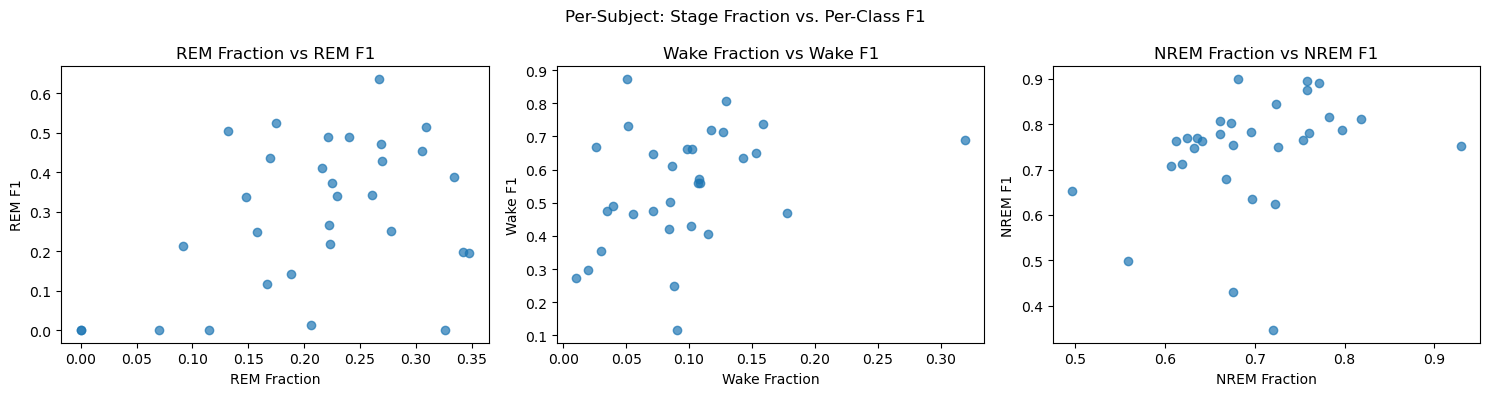

In [8]:
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

subject_stats = []
for sid in sorted(epoch_df['subject_id'].unique()):
    mask = (epoch_df['subject_id'] == sid).values
    if mask.sum() == 0:
        continue
    y_true_s = y.values[mask] if hasattr(y, 'values') else y[mask]
    y_pred_s = y_pred_final[mask]
    n_epochs = mask.sum()
    rem_frac  = (y_true_s == 'REM').mean()
    wake_frac = (y_true_s == 'Wake').mean()
    nrem_frac = (y_true_s == 'NREM').mean()
    f1_per_class = f1_score(y_true_s, y_pred_s, average=None,
                             labels=classes, zero_division=0)
    f1_macro = f1_score(y_true_s, y_pred_s, average='macro', zero_division=0)
    subject_stats.append({
        'subject_id': sid, 'n_epochs': n_epochs,
        'rem_frac': rem_frac, 'wake_frac': wake_frac, 'nrem_frac': nrem_frac,
        'f1_macro': f1_macro,
        **{f'f1_{cls}': f1_per_class[i] for i, cls in enumerate(classes)}
    })

subject_df = pd.DataFrame(subject_stats)
print(f"Per-Subject F1 Macro: {subject_df['f1_macro'].mean():.4f} +/- {subject_df['f1_macro'].std():.4f}")
print(f"  Min: {subject_df['f1_macro'].min():.4f}  Max: {subject_df['f1_macro'].max():.4f}")
print()
print(subject_df[['subject_id', 'f1_macro', 'rem_frac', 'wake_frac', 'nrem_frac']].to_string(index=False))

# --- 7.A Per-Subject Diagnostic: Stage Fraction vs. Per-Class F1 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x_col, x_label, y_col, y_label) in zip(axes, [
    ('rem_frac',  'REM Fraction',  'f1_REM',   'REM F1'),
    ('wake_frac', 'Wake Fraction', 'f1_Wake',  'Wake F1'),
    ('nrem_frac', 'NREM Fraction', 'f1_NREM',  'NREM F1'),
]):
    ax.scatter(subject_df[x_col], subject_df[y_col], alpha=0.7)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{x_label} vs {y_label}')
plt.suptitle('Per-Subject: Stage Fraction vs. Per-Class F1')
plt.tight_layout()
plt.show()

## 8. Hypnogram Visualization

Compare predicted vs. true sleep staging for one example subject. Hypnograms are the standard visualization in sleep medicine and provide intuitive assessment of temporal prediction accuracy.

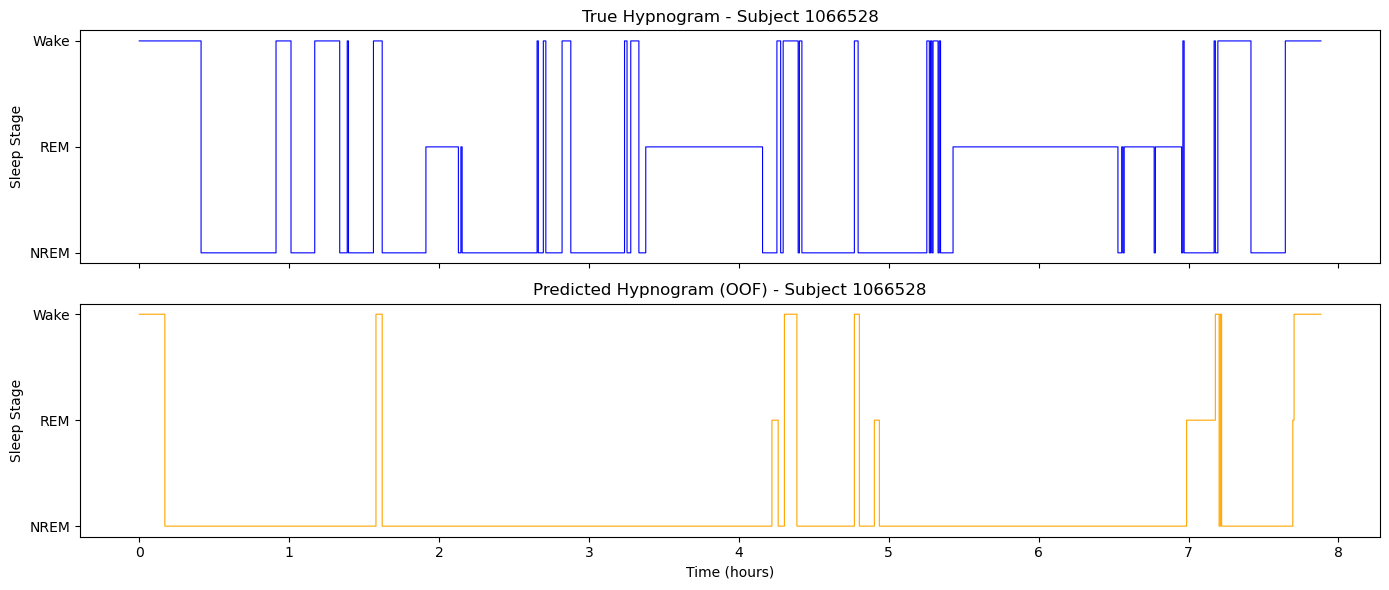

In [9]:
import matplotlib.pyplot as plt

# Pick the first subject deterministically
example_subject = sorted(epoch_df['subject_id'].unique())[0]
mask = (epoch_df['subject_id'] == example_subject).values

epochs = epoch_df.loc[mask, 'epoch_start'].values
y_true_subj = y.values[mask] if hasattr(y, 'values') else y[mask]
y_pred_subj = y_pred_final[mask]

stage_order = {'Wake': 2, 'REM': 1, 'NREM': 0}
ytick_labels = ['NREM', 'REM', 'Wake']

true_numeric = [stage_order[s] for s in y_true_subj]
pred_numeric = [stage_order[s] for s in y_pred_subj]

hours = (epochs - epochs[0]) / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].step(hours, true_numeric, where='mid', color='blue', linewidth=0.8)
axes[0].set_yticks(range(len(ytick_labels)))
axes[0].set_yticklabels(ytick_labels)
axes[0].set_title(f'True Hypnogram - Subject {example_subject}')
axes[0].set_ylabel('Sleep Stage')

axes[1].step(hours, pred_numeric, where='mid', color='orange', linewidth=0.8)
axes[1].set_yticks(range(len(ytick_labels)))
axes[1].set_yticklabels(ytick_labels)
axes[1].set_title(f'Predicted Hypnogram (OOF) - Subject {example_subject}')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Sleep Stage')

plt.tight_layout()
plt.show()